# Read data

In [4]:
import numpy as np
import matplotlib.pyplot as plt

import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
import pandas as pd

cm = 1/2.54
fontsize = 10


def plot_heatmap(data, metrics, use_annot=True, sort_by='internal_energy', save_file="Fig2a_PB_Heatmap_v2.pdf"):
    """
    Plots a heatmap where rows are models and columns are metrics,
    sorted by a specific metric (e.g., internal_energy).
    """
    factor_labels = {
        'internal_energy': 'Internal Energy',
        'minimum_distance_to_protein': 'Protein Min. Distance',
        'protein-ligand_maximum_distance': 'Protein-Ligand Max. Distance',
        'internal_steric_clash': 'Internal Steric Clash',
        'bond_lengths': 'Bond Lengths',
        'bond_angles': 'Bond Angles',
        'aromatic_ring_flatness': 'Aromatic Ring Flatness',
        'double_bond_flatness': 'Double Bond Flatness',
        'volume_overlap_with_protein': 'Protein Volume Overlap',
        'pass_all': 'PB Valid',
    }

    df_denovo = pd.DataFrame(index=[factor_labels[m] for m in metrics])
    for model_name, model_data in data["De novo"].items():
        df_denovo[model_name] = [model_data.get(m, np.nan) for m in metrics]
    
    df_denovo = df_denovo.loc[:, df_denovo.loc[sort_by].sort_values(ascending=False).index]

    df_hit2lead = pd.DataFrame(index=[factor_labels[m] for m in metrics])
    for model_name, model_data in data["Hit to Lead"].items():
        df_hit2lead[model_name] = [model_data.get(m, np.nan) for m in metrics]
    
    df_hit2lead = df_hit2lead.loc[:, df_hit2lead.loc[sort_by].sort_values(ascending=False).index]

    df_final = pd.concat([df_denovo, df_hit2lead], axis=1)

    plt.figure(figsize=(9,4.5), dpi=300)
    sns.set(font_scale=1.0)

    colors = [
        (0.0, '#d73027'),  
        (0.25, '#fc8d59'), 
        (0.5, '#fee08b'),  
        (1.0, '#1a9850') 
    ]

    cmap = LinearSegmentedColormap.from_list("custom_gradient", colors)
    ax = sns.heatmap(
        df_final,
        annot=use_annot,
        fmt=".3f",
        # cmap="Greens",
        cmap=cmap,
        # vmin=0.3,
        vmin=0.0,
        vmax=1.0,
        linewidths=0.5,
        linecolor="gray",
        annot_kws={"fontsize":fontsize-3.5}   #7
    )

    cbar = ax.collections[0].colorbar
    cbar.ax.tick_params(labelsize=fontsize-3)

    
    cbar.set_label("Pass Rate",fontdict={'size': fontsize-2})  #8
    ax.tick_params(
        axis='both',        
        which='both',       
        direction='inout', 
        length=4,           
        width=0.8,          
        colors='black',     
        bottom=False, top=True, left=True, right=False  
    )

    ax.xaxis.tick_top()                  
    ax.xaxis.set_label_position('top')   
    plt.xticks(rotation=45, ha='left',rotation_mode='anchor',fontsize=fontsize-2.5)  #7.5
    plt.yticks(fontsize=fontsize-2)  #8
        
    y_line = 1.23    
    y_text = 1.25    
    
    group_map =  {
        'De novo': list(data['De novo'].keys()),
        'Hit to Lead': list(data['Hit to Lead'].keys())
    }
    
    for label, model_names in group_map.items():
        
        idxs = [list(df_final.columns).index(name) for name in model_names if name in df_final.columns]
        
        if label == 'De novo':
            x_start = min(idxs) + 0.5
            x_end = max(idxs) + 0.5
        if label == 'Hit to Lead':
            x_start = 9.5
            x_end = 13.5

        x_center = (x_start + x_end) / 2
        
        ax.plot([x_start-0.2, x_end+0.2], [y_line, y_line], 
                color='black', linewidth=0.6, clip_on=False, transform=ax.get_xaxis_transform())
        
        # 写分组名（denovo / hit2lead）
        ax.text(x_center, y_text, label,
                ha='center', va='bottom', fontsize=9,
                clip_on=False, transform=ax.get_xaxis_transform())
    


    plt.tight_layout()
    plt.savefig(save_file, format="svg", bbox_inches='tight')
    plt.show()

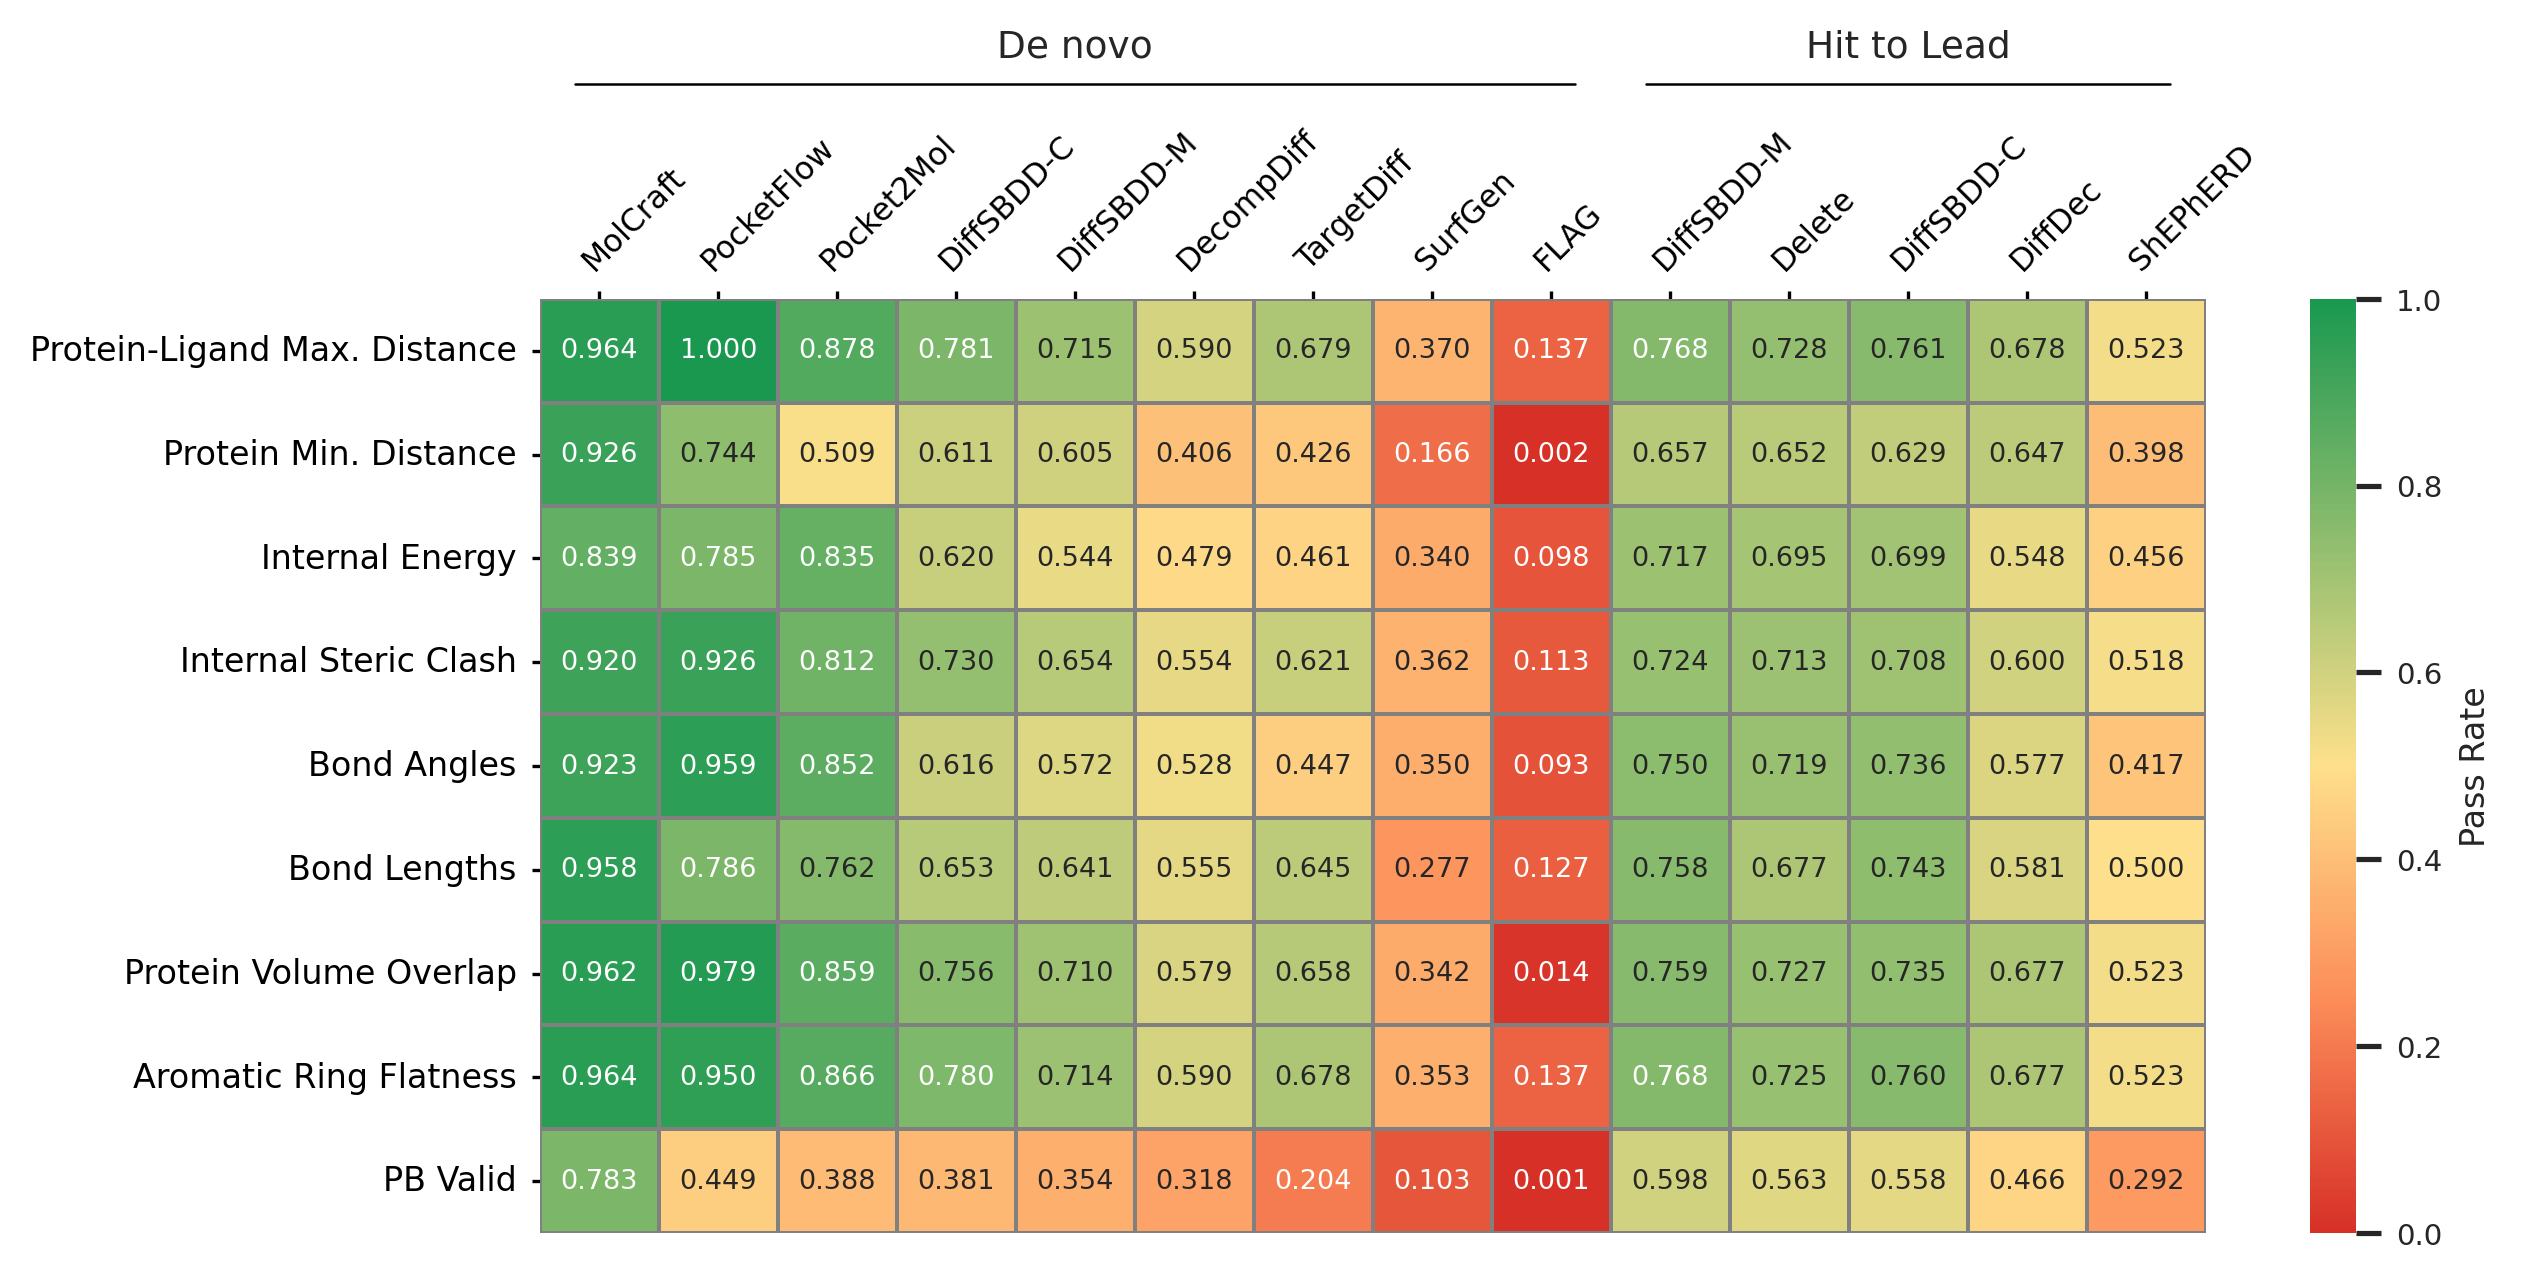

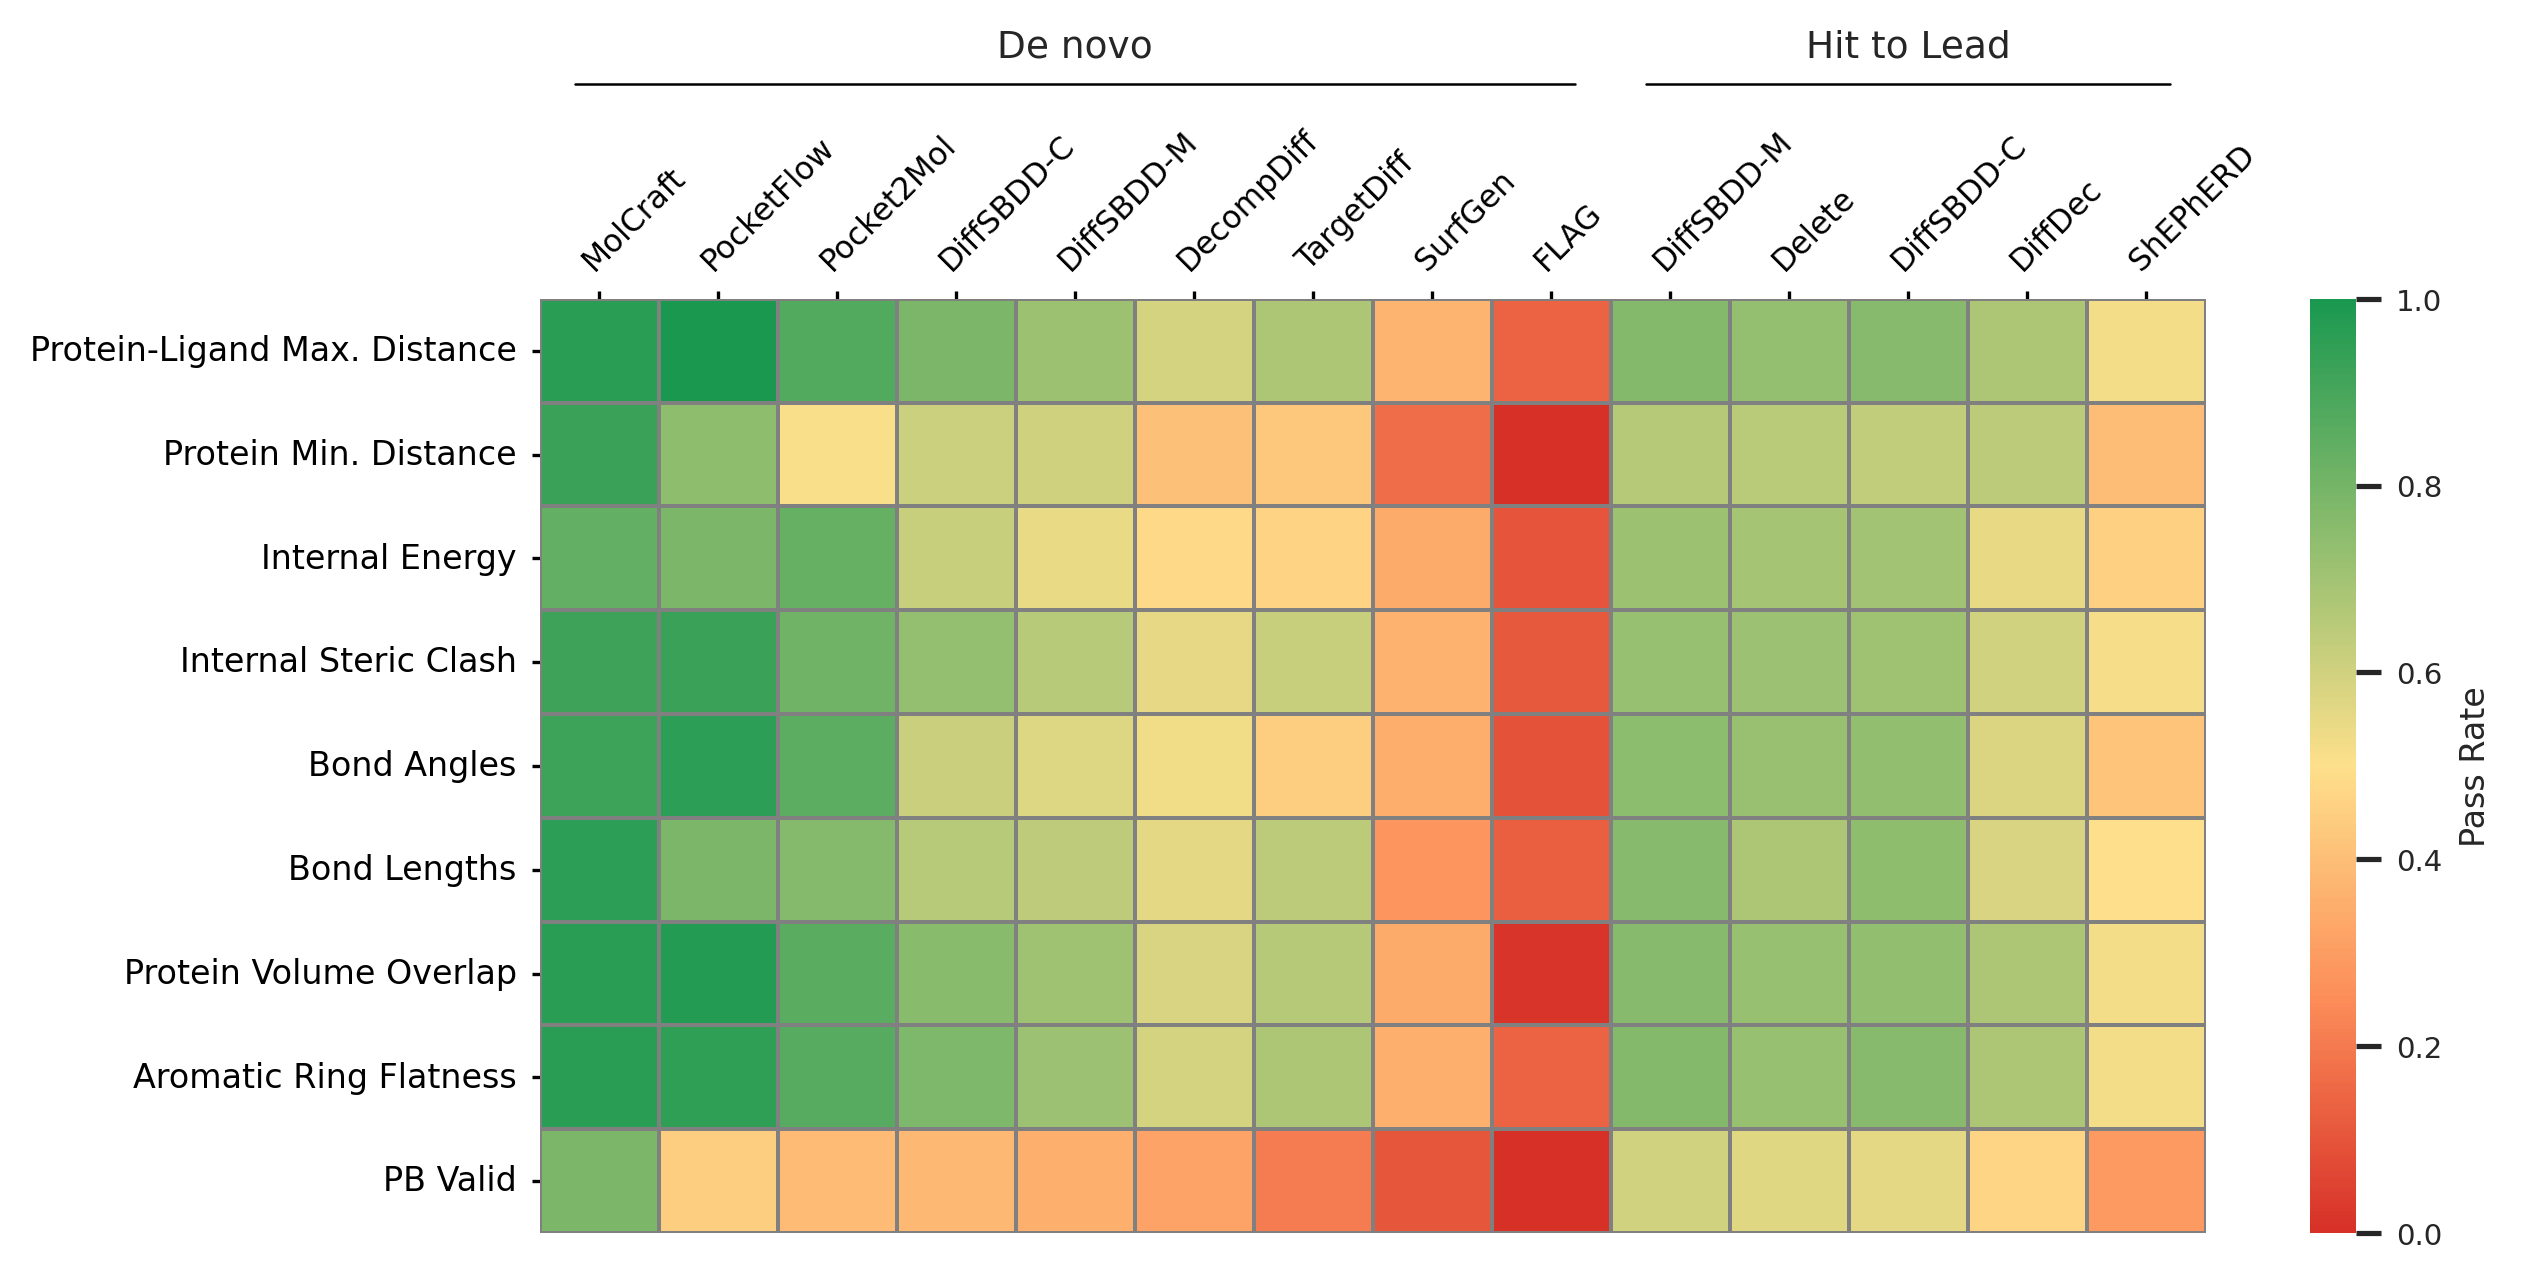

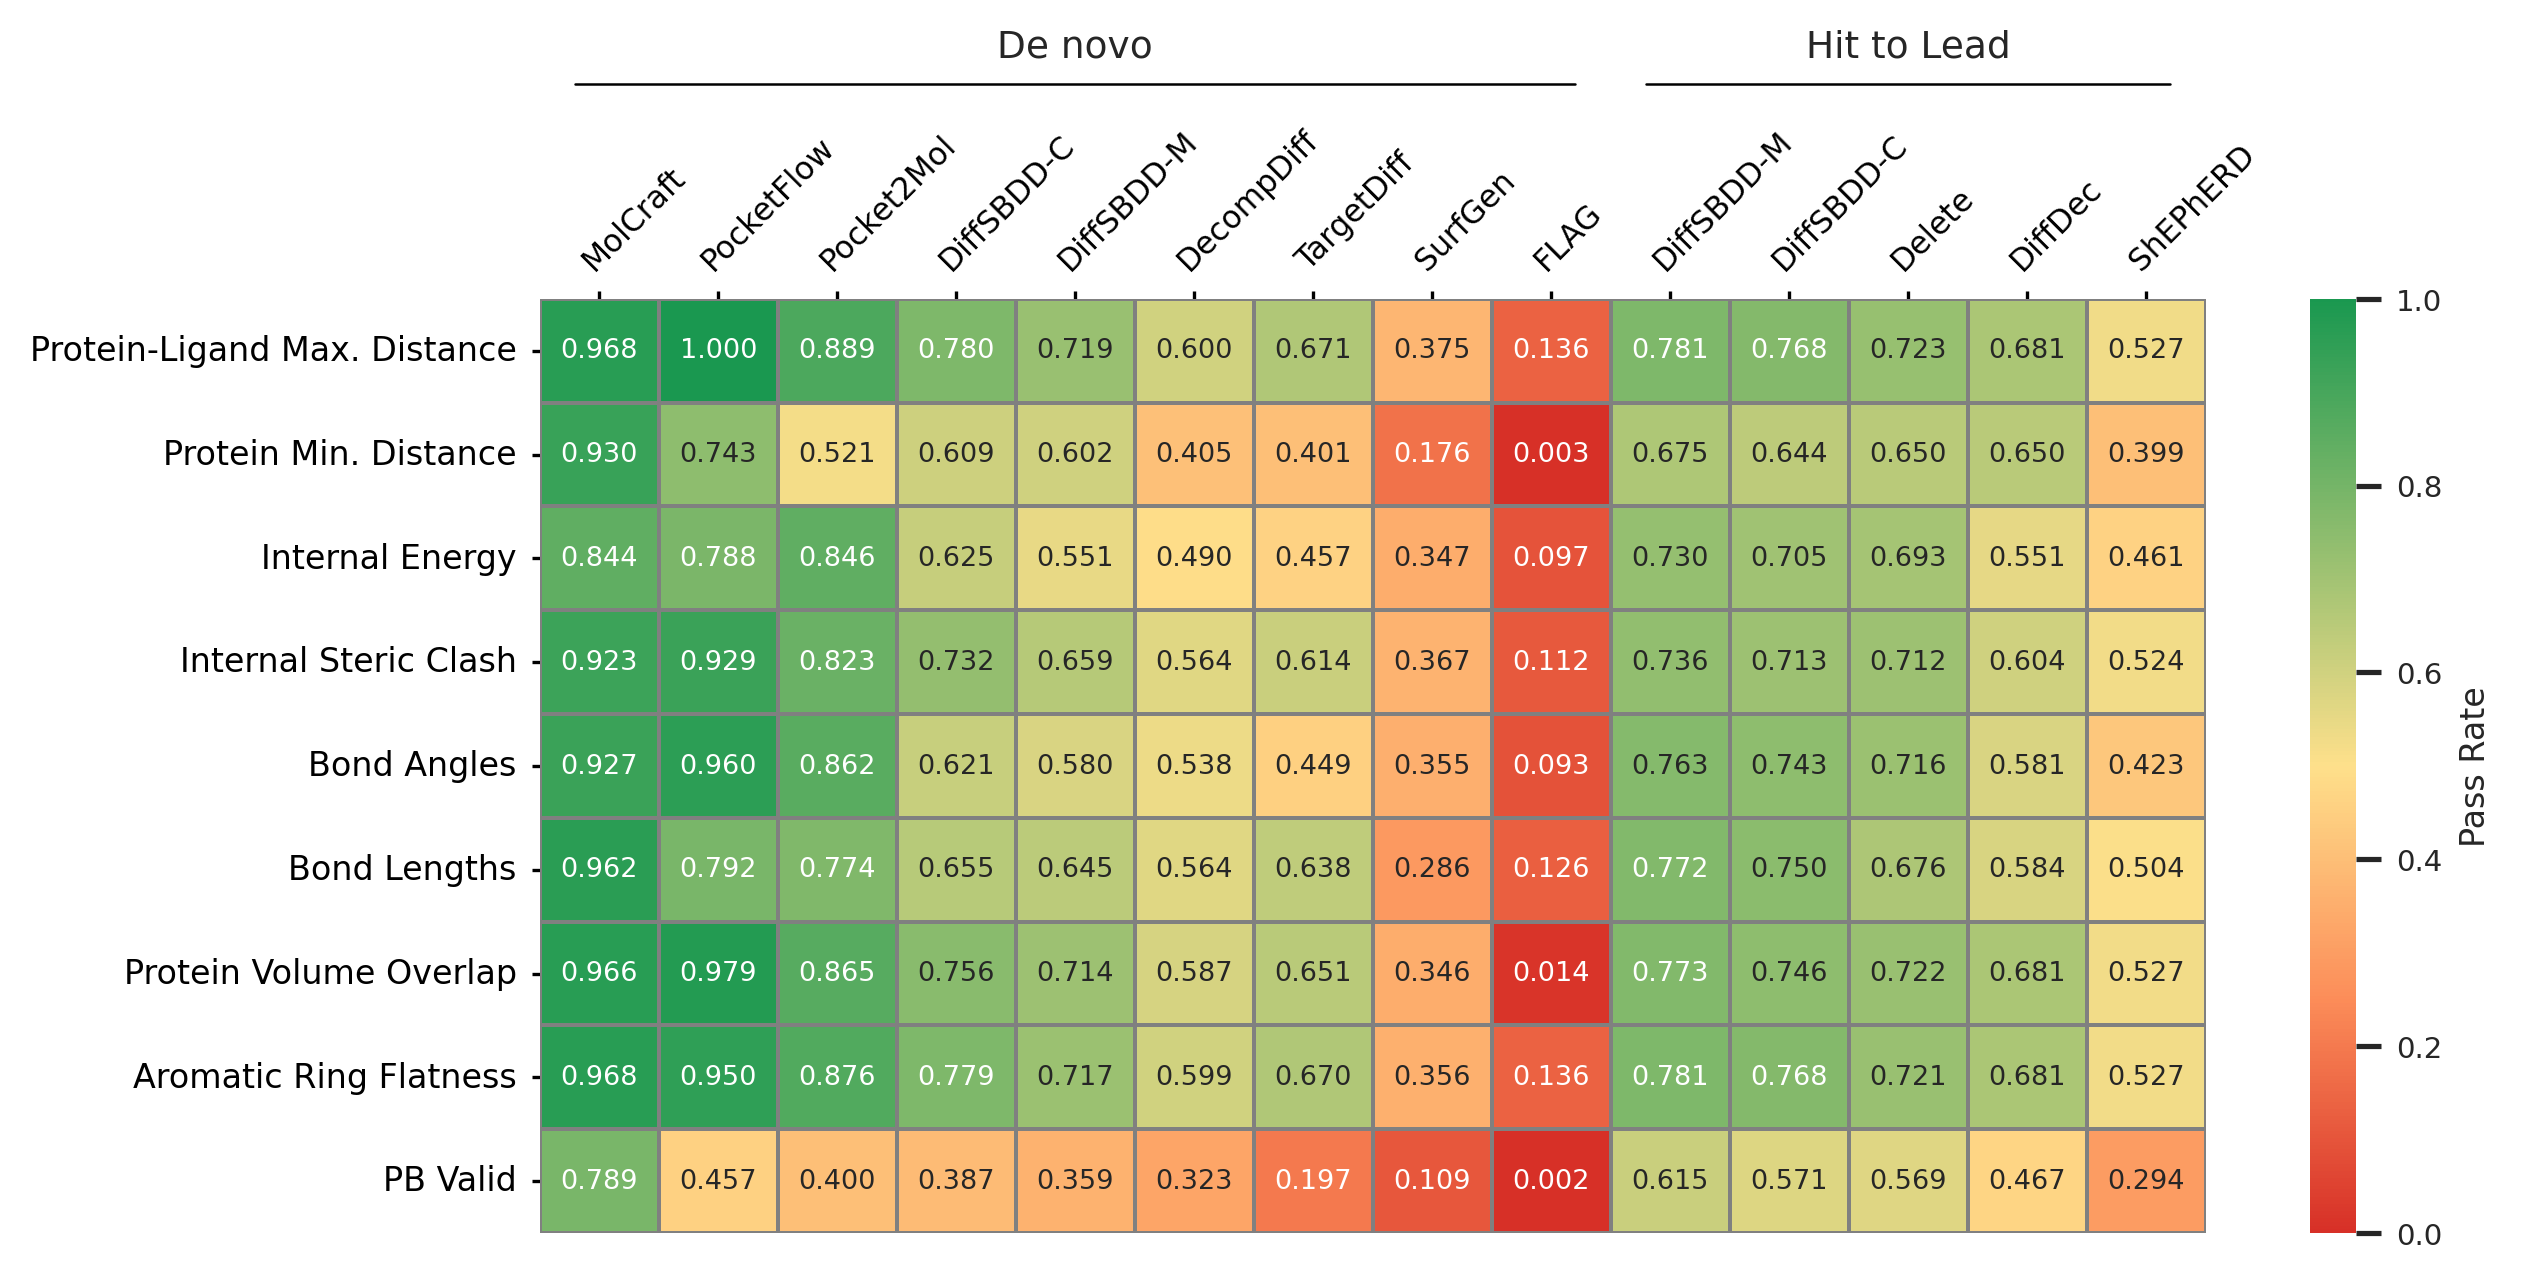

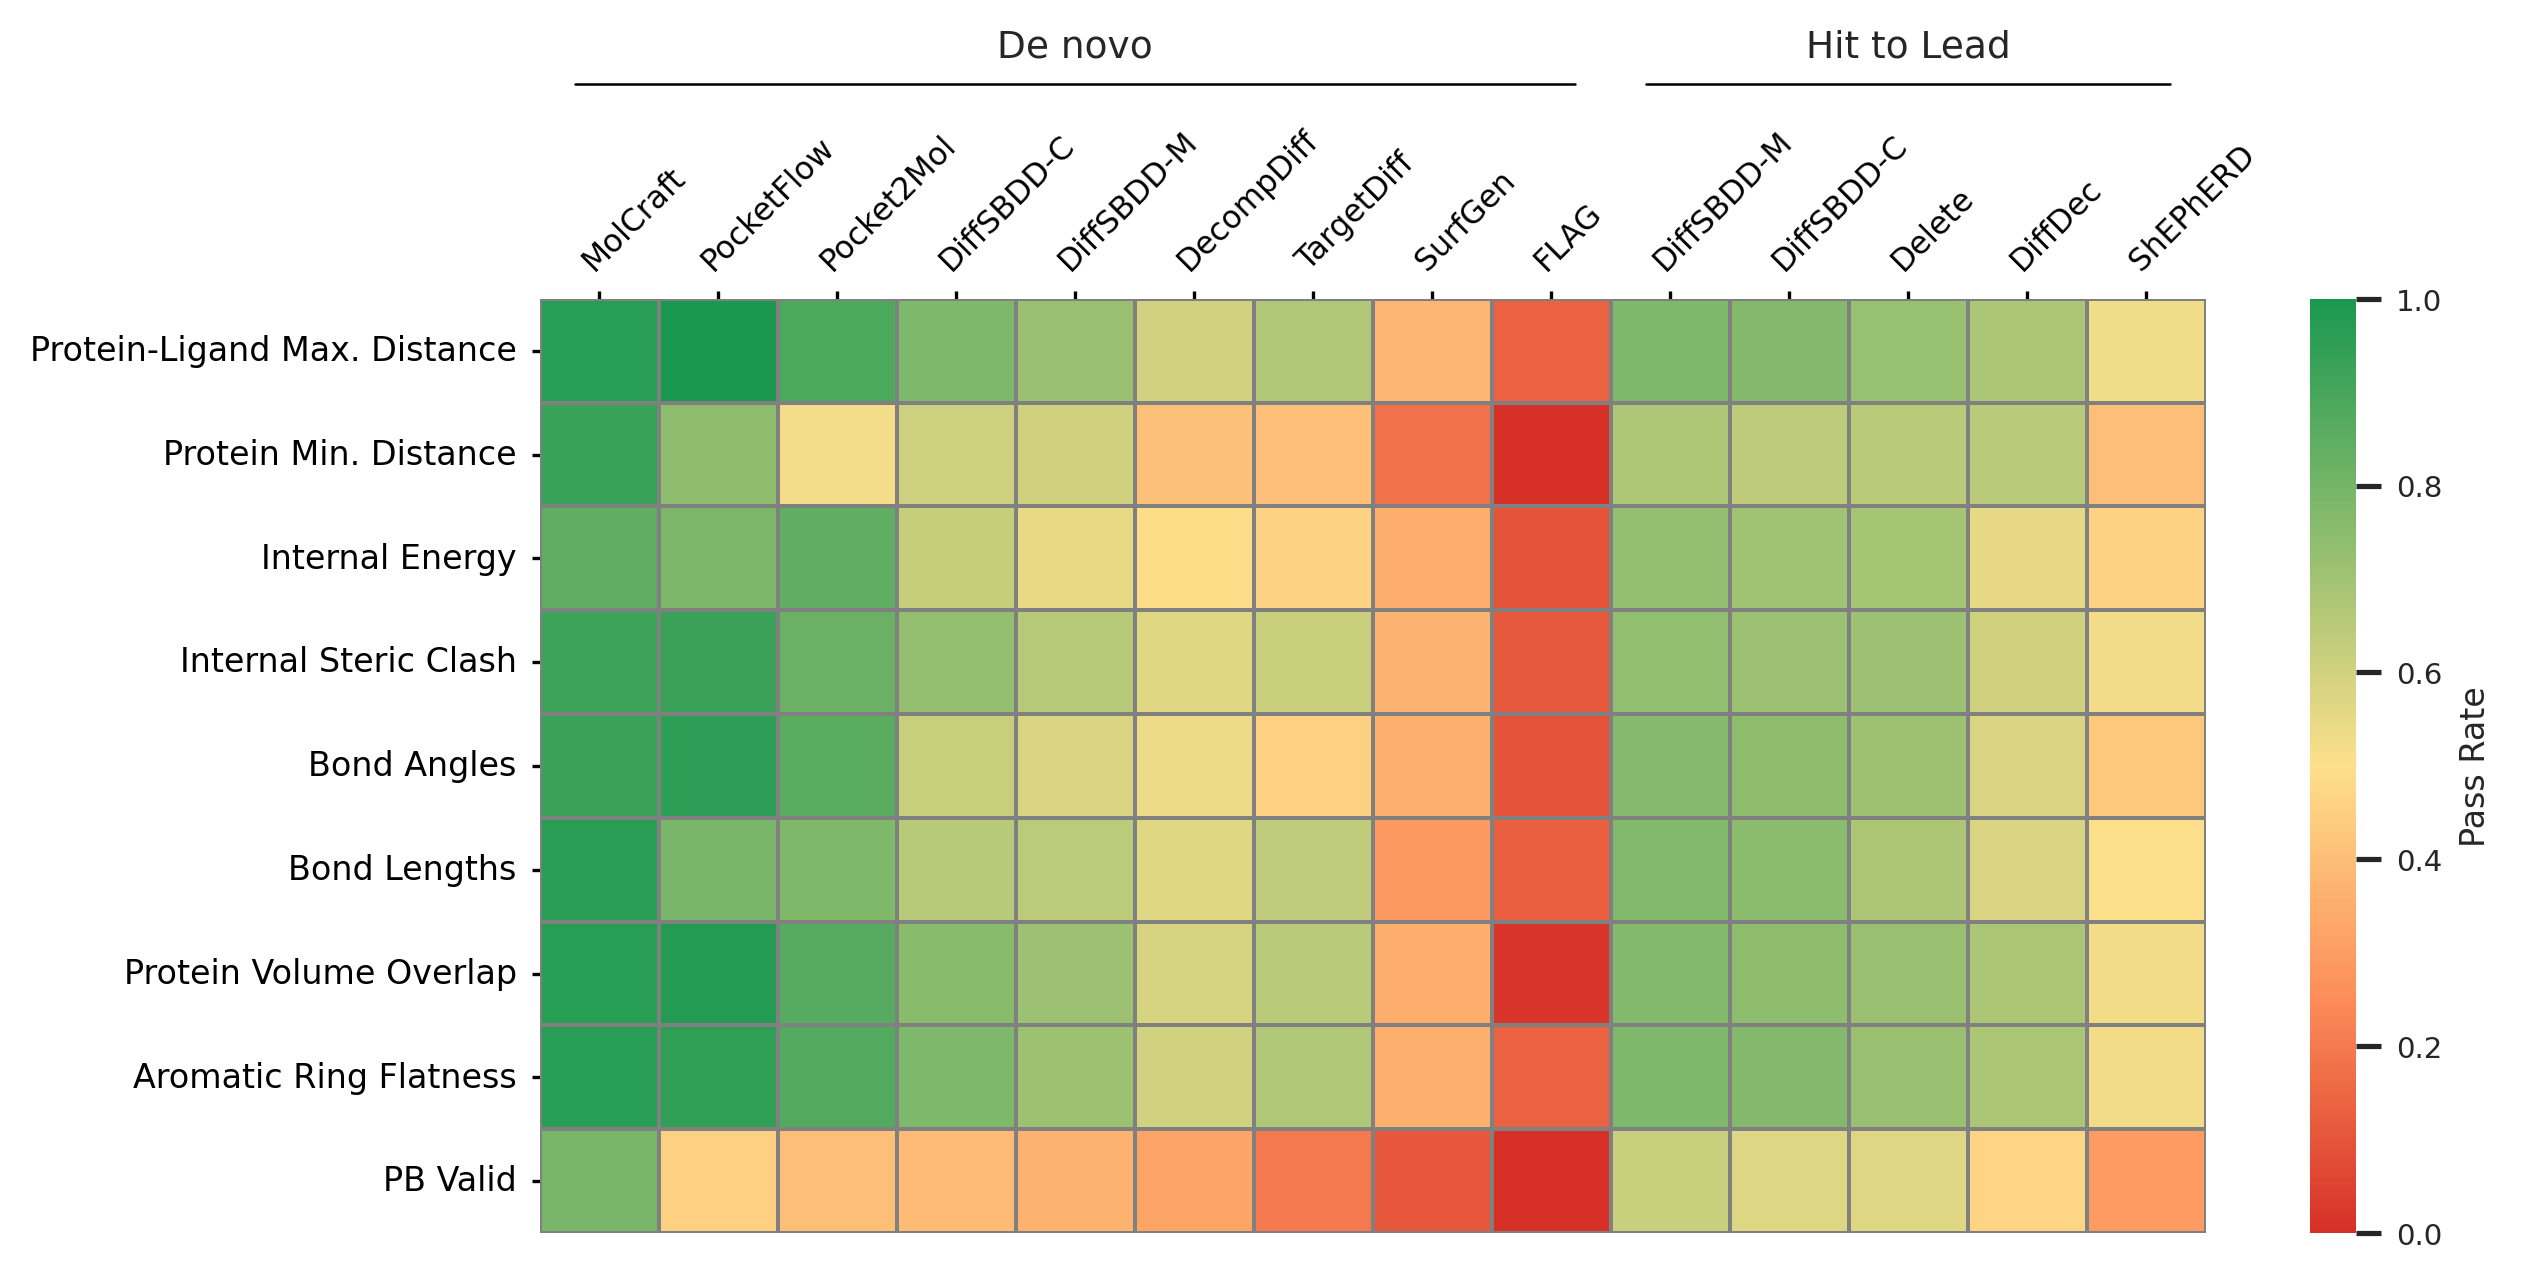

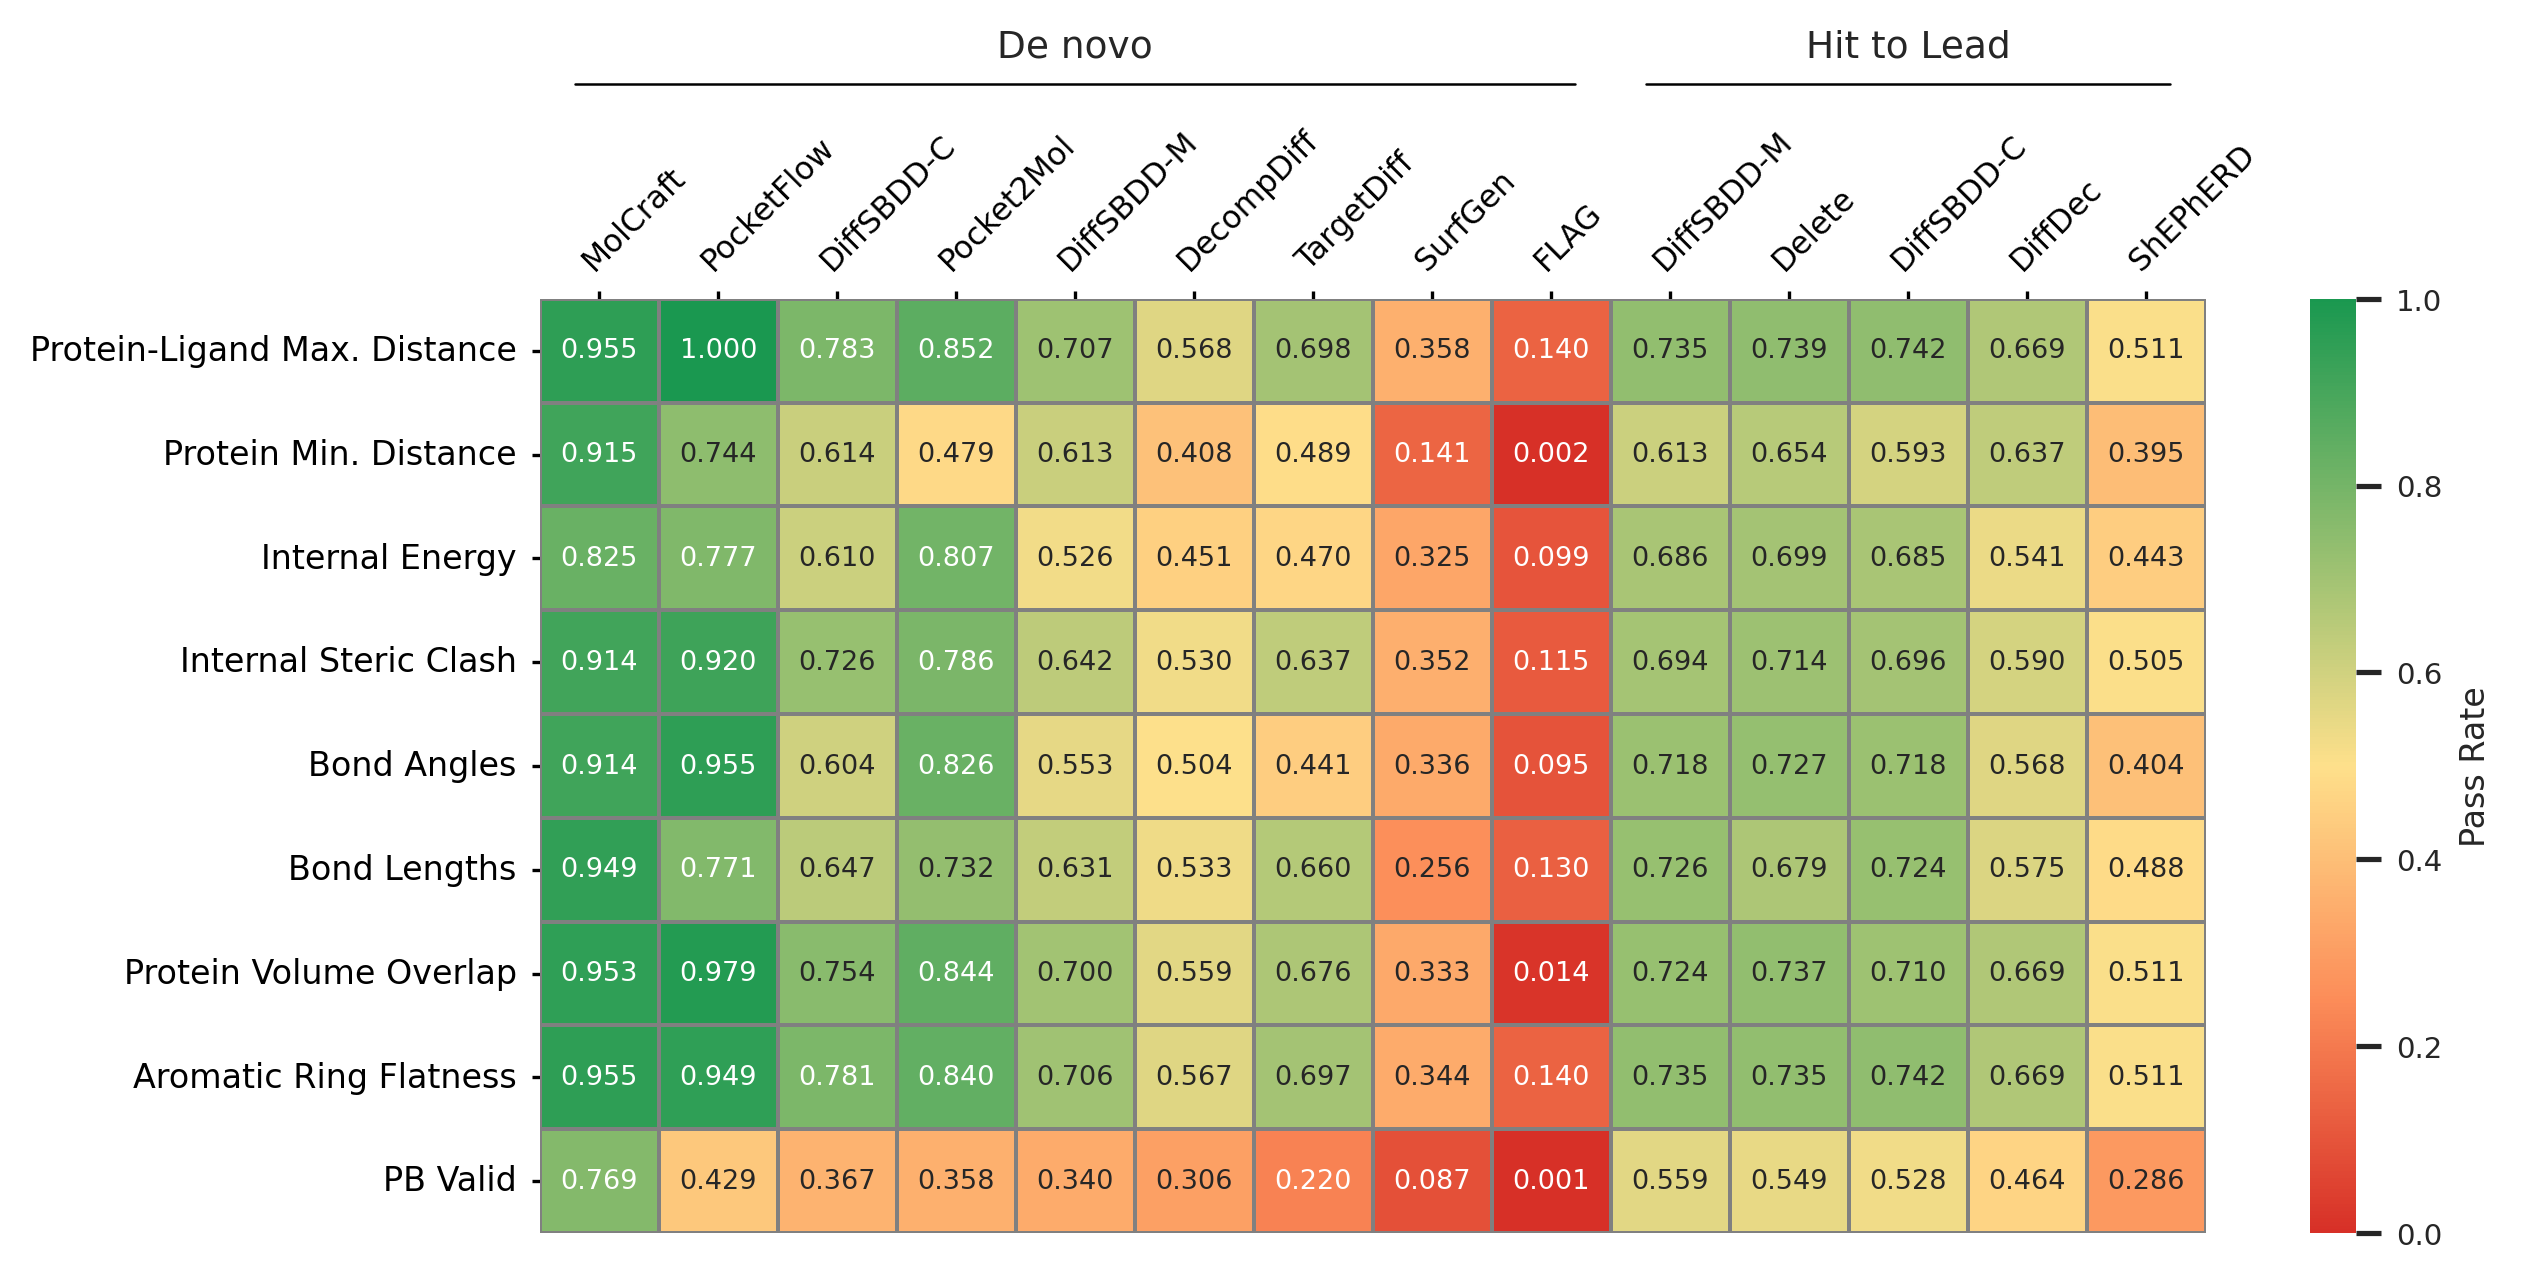

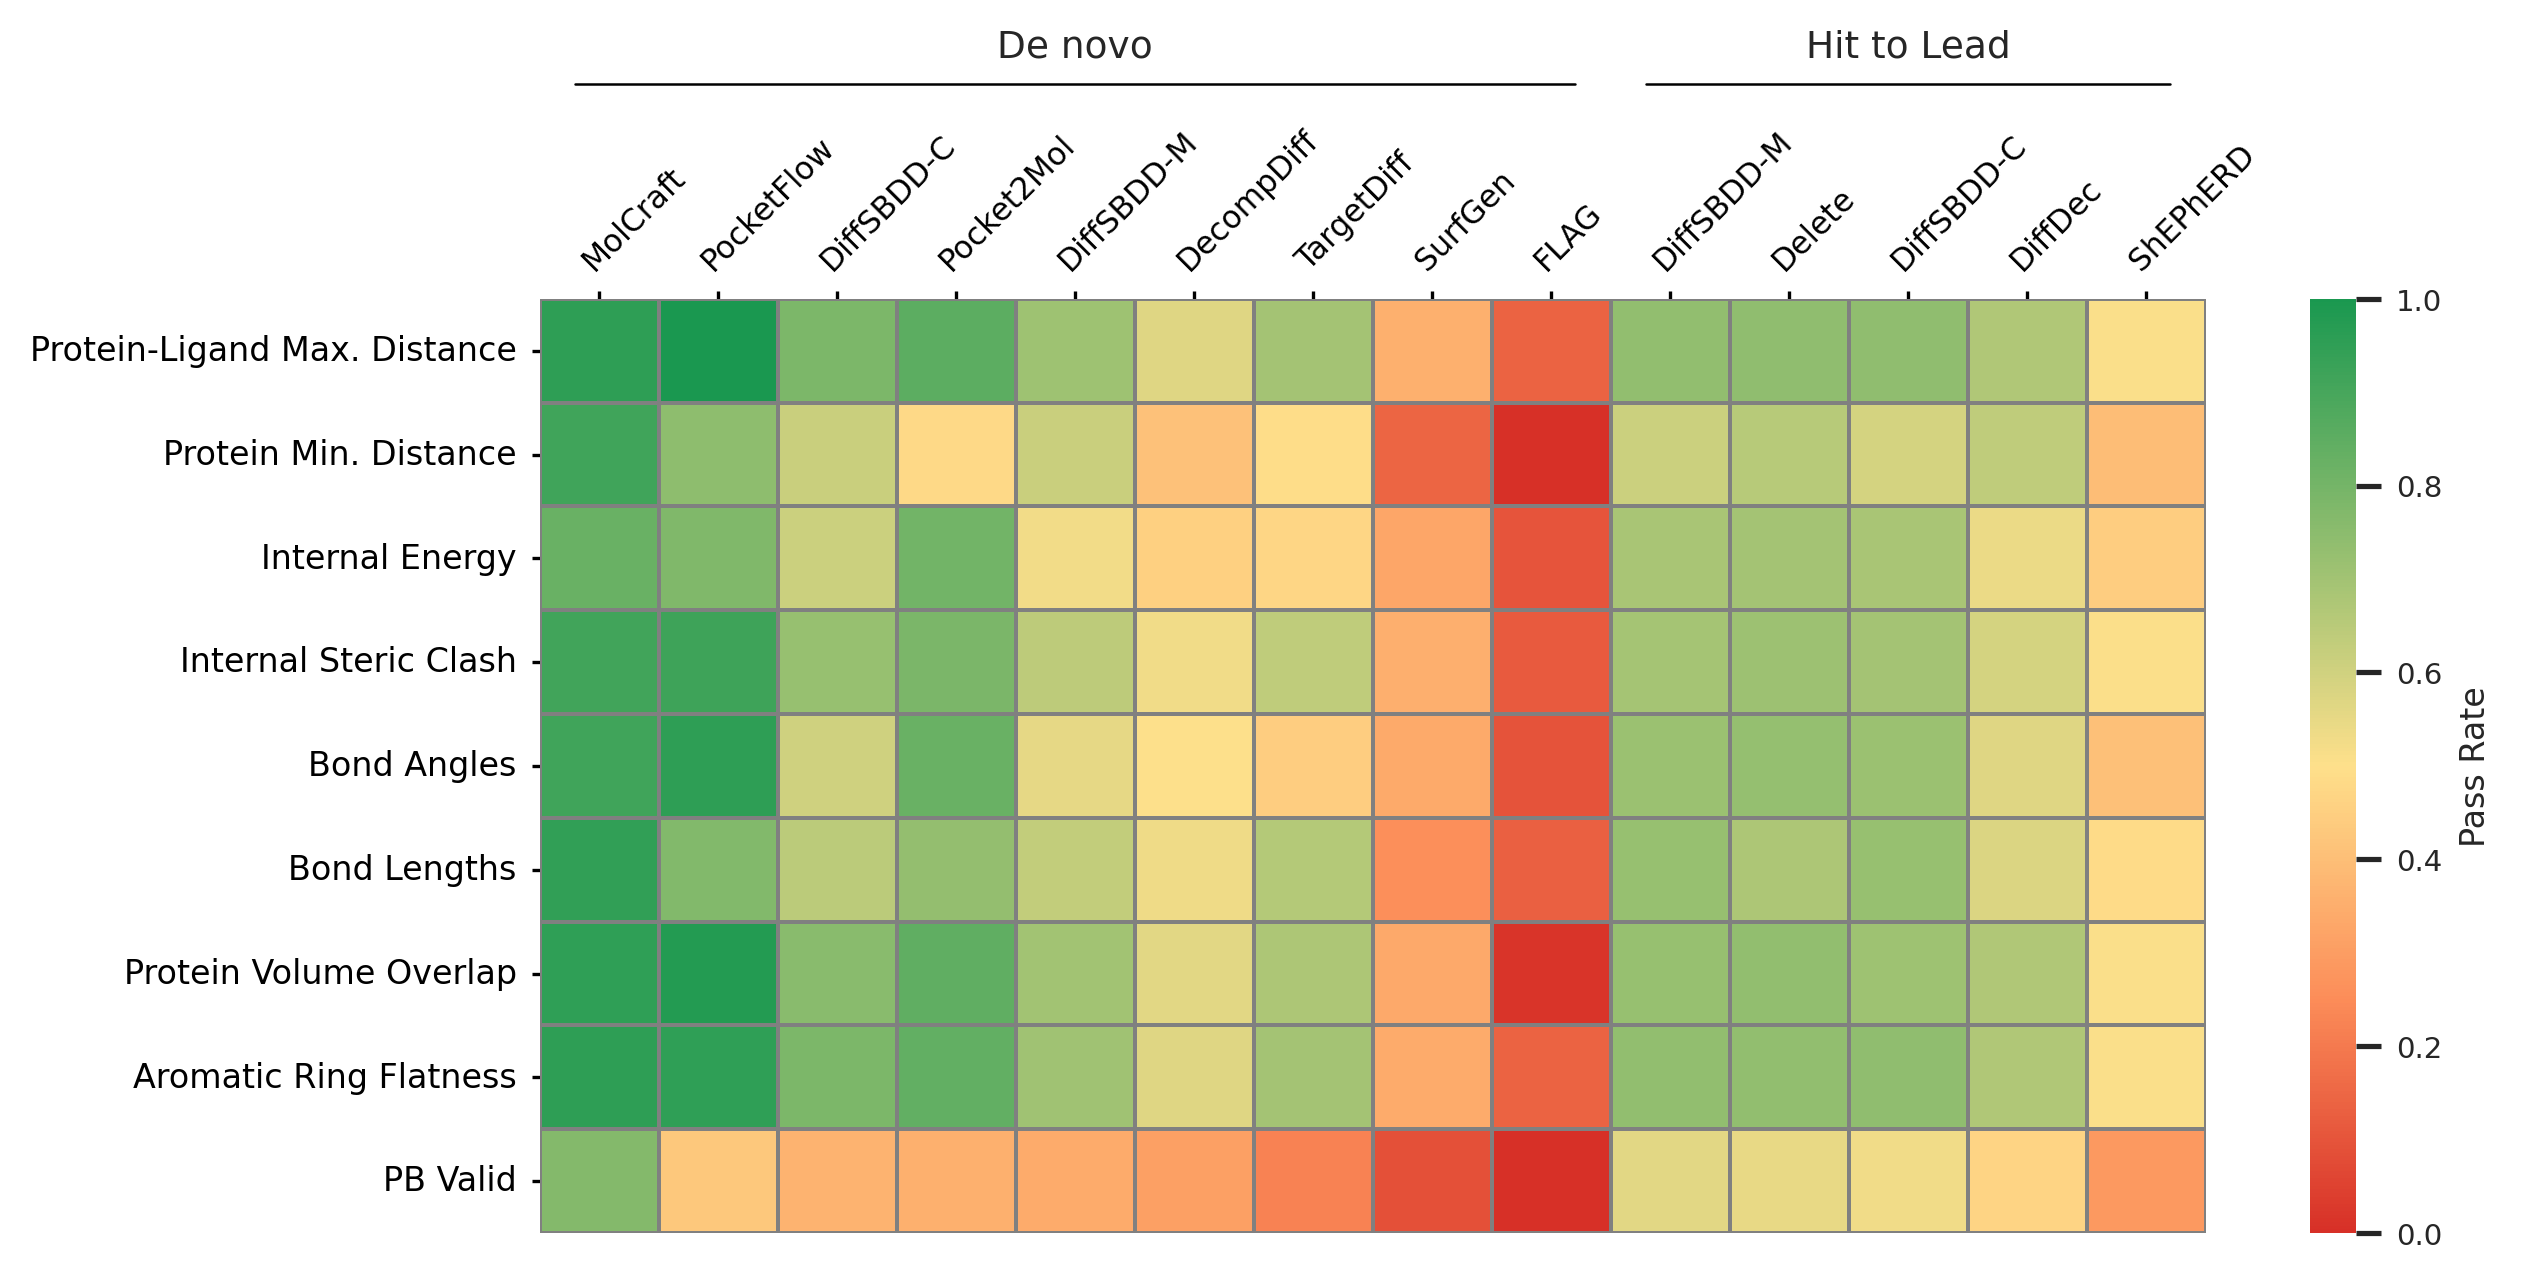

In [ ]:
import os
import pandas as pd
import numpy as np
import yaml
import seaborn as sns
import matplotlib.pyplot as plt


data_path = "/home/user-home/fanzhehuan/myprojects/MolGenBench/paper_results"

round_list = ["Round1", "Round2", "Round3"]
mode_list = ["De_novo_Results", "Hit_to_Lead_Results"]


TASK_LIST_DENOVO = [
    'MolCraft_generated_molecules',
    'DecompDiff_generated_molecules',
    'FLAG_generated_molecules',
    'PocketFlow_generated_molecules',
    'SurfGen_generated_molecules',
    'TargetDiff_generated_molecules',
    # 'TamGen_generated_molecules',
    "Pocket2Mol_generated_molecules",
    "diffSBDD_cond_crossdocked_generated_molecules",
    "diffSBDD_cond_moad_generated_molecules"
]

DENOVO_NAME_MAPPING = {
    "MolCraft_generated_molecules": "MolCraft",
    "DecompDiff_generated_molecules": "DecompDiff",
    "FLAG_generated_molecules": "FLAG",
    "PocketFlow_generated_molecules": "PocketFlow",
    "SurfGen_generated_molecules": "SurfGen",
    "TargetDiff_generated_molecules": "TargetDiff",
    # "TamGen_generated_molecules": "TamGen",
    "Pocket2Mol_generated_molecules": "Pocket2Mol",
    "diffSBDD_cond_crossdocked_generated_molecules": "DiffSBDD-C",
    "diffSBDD_cond_moad_generated_molecules": "DiffSBDD-M",
}

TASK_LIST_H2L = [
    "DeleteHit2Lead(CrossDock)_Hit_to_Lead",
    "DiffDec_Hit_to_Lead",
    "diffSBDD_cond_crossdocked_Hit_to_Lead",
    "diffSBDD_cond_moad_Hit_to_Lead",
    # "PGMG_Hit_to_Lead",
    # "ShapeMol_Hit_to_Lead",
    "shepherd_x1x3x4_mosesaq_submission_Hit_to_Lead",
]

H2L_NAME_MAPPING = {
    "DiffDec_Hit_to_Lead": "DiffDec",
    "diffSBDD_cond_crossdocked_Hit_to_Lead": "DiffSBDD-C",
    "diffSBDD_cond_moad_Hit_to_Lead": "DiffSBDD-M",
    # "ShapeMol_Hit_to_Lead": "ShapeMol",
    "shepherd_x1x3x4_mosesaq_submission_Hit_to_Lead": "ShEPhERD",
    "DeleteHit2Lead(CrossDock)_Hit_to_Lead": "Delete",
    # "PGMG_Hit_to_Lead": "PGMG",
}


all_key = [
      "mol_cond_loaded",
      "sanitization",
      "inchi_convertible",
      "all_atoms_connected",
      "bond_lengths",
      "bond_angles",
      "internal_steric_clash",
      "aromatic_ring_flatness",
      "double_bond_flatness",
      "internal_energy",
      "protein-ligand_maximum_distance",
      "minimum_distance_to_protein",
      "minimum_distance_to_organic_cofactors",
      "minimum_distance_to_inorganic_cofactors",
      "minimum_distance_to_waters",
      "volume_overlap_with_protein",
      "volume_overlap_with_organic_cofactors",
      "volume_overlap_with_inorganic_cofactors",
      "volume_overlap_with_waters",
      "pass_all",
]

results_all = []
results_seen = []
results_unseen = []

for round_name in round_list:
    for mode in mode_list:
        if mode == "De_novo_Results":
            task_list = TASK_LIST_DENOVO
            name_mapping = DENOVO_NAME_MAPPING
            task_type = "De novo"
        else:
            task_list = TASK_LIST_H2L
            name_mapping = H2L_NAME_MAPPING
            task_type = "Hit to Lead"
        
        for task in task_list:
            yaml_path = os.path.join(data_path, round_name, mode, task, "results.yaml")
            with open(yaml_path, 'r') as f:
                result = yaml.safe_load(f)

                results_all.append({
                    "Model": name_mapping[task],
                    "Round": round_name,
                    "Type": task_type,
                    **result['metrics']['PoseBuster']['all'],
                })
                
                results_seen.append({
                    "Model": name_mapping[task],
                    "Round": round_name,
                    "Type": task_type,
                    **result['metrics']['PoseBuster']['seen'],
                })
                
                results_unseen.append({
                    "Model": name_mapping[task],
                    "Round": round_name,
                    "Type": task_type,
                    **result['metrics']['PoseBuster']['unseen'],
                })
                

df_results_all = pd.DataFrame(results_all)
df_results_seen = pd.DataFrame(results_seen)
df_results_unseen = pd.DataFrame(results_unseen)

df_mean_all = (
    df_results_all
    .groupby(["Model", "Type"], as_index=False)[all_key]
    .mean()
)

df_mean_seen = (
    df_results_seen
    .groupby(["Model", "Type"], as_index=False)[all_key]
    .mean()
)

df_mean_unseen = (
    df_results_unseen
    .groupby(["Model", "Type"], as_index=False)[all_key]
    .mean()
)

def df_to_nested_dict(df_mean):
    data_dict = {
        "De novo": {},
        "Hit to Lead": {}
    }
    
    for _, row in df_mean.iterrows():
        model_name = row["Model"]
        task_type = row["Type"]
        
        # 提取所有 metric 值（排除 Model 和 Type 列）
        metrics_dict = row.drop(["Model", "Type"]).to_dict()
        
        data_dict[task_type][model_name] = metrics_dict
    
    return data_dict

data_all = df_to_nested_dict(df_mean_all)
data_seen = df_to_nested_dict(df_mean_seen)
data_unseen = df_to_nested_dict(df_mean_unseen)

top_8_keys = [
    "protein-ligand_maximum_distance",
    'minimum_distance_to_protein',
    'internal_energy',
    'internal_steric_clash',
    'bond_angles',
    'bond_lengths',
    'volume_overlap_with_protein',
    'aromatic_ring_flatness',
    'pass_all',
]

plot_heatmap(data_all, top_8_keys, sort_by='PB Valid', save_file="../final_plot/output/02-posebuster_heatmap_all_fixAtomConnect.svg")
plot_heatmap(data_all, top_8_keys, use_annot=False,sort_by='PB Valid', save_file="../final_plot/output/02-posebuster_heatmap_all_NoNumber_fixAtomConnect.svg")

plot_heatmap(data_seen, top_8_keys, sort_by='PB Valid', save_file="../final_plot/output/02-posebuster_heatmap_seen_fixAtomConnect.svg")
plot_heatmap(data_seen, top_8_keys, use_annot=False,sort_by='PB Valid', save_file="../final_plot/output/02-posebuster_heatmap_seen_NoNumber_fixAtomConnect.svg")

plot_heatmap(data_unseen, top_8_keys, sort_by='PB Valid', save_file="../final_plot/output/02-posebuster_heatmap_unseen_fixAtomConnect.svg")
plot_heatmap(data_unseen, top_8_keys, use_annot=False,sort_by='PB Valid', save_file="../final_plot/output/02-posebuster_heatmap_unseen_NoNumber_fixAtomConnect.svg")

# bar plot

/tmp/ipykernel_4095318/890990269.py:227: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(new_labels, rotation=70, ha="right", rotation_mode='anchor')


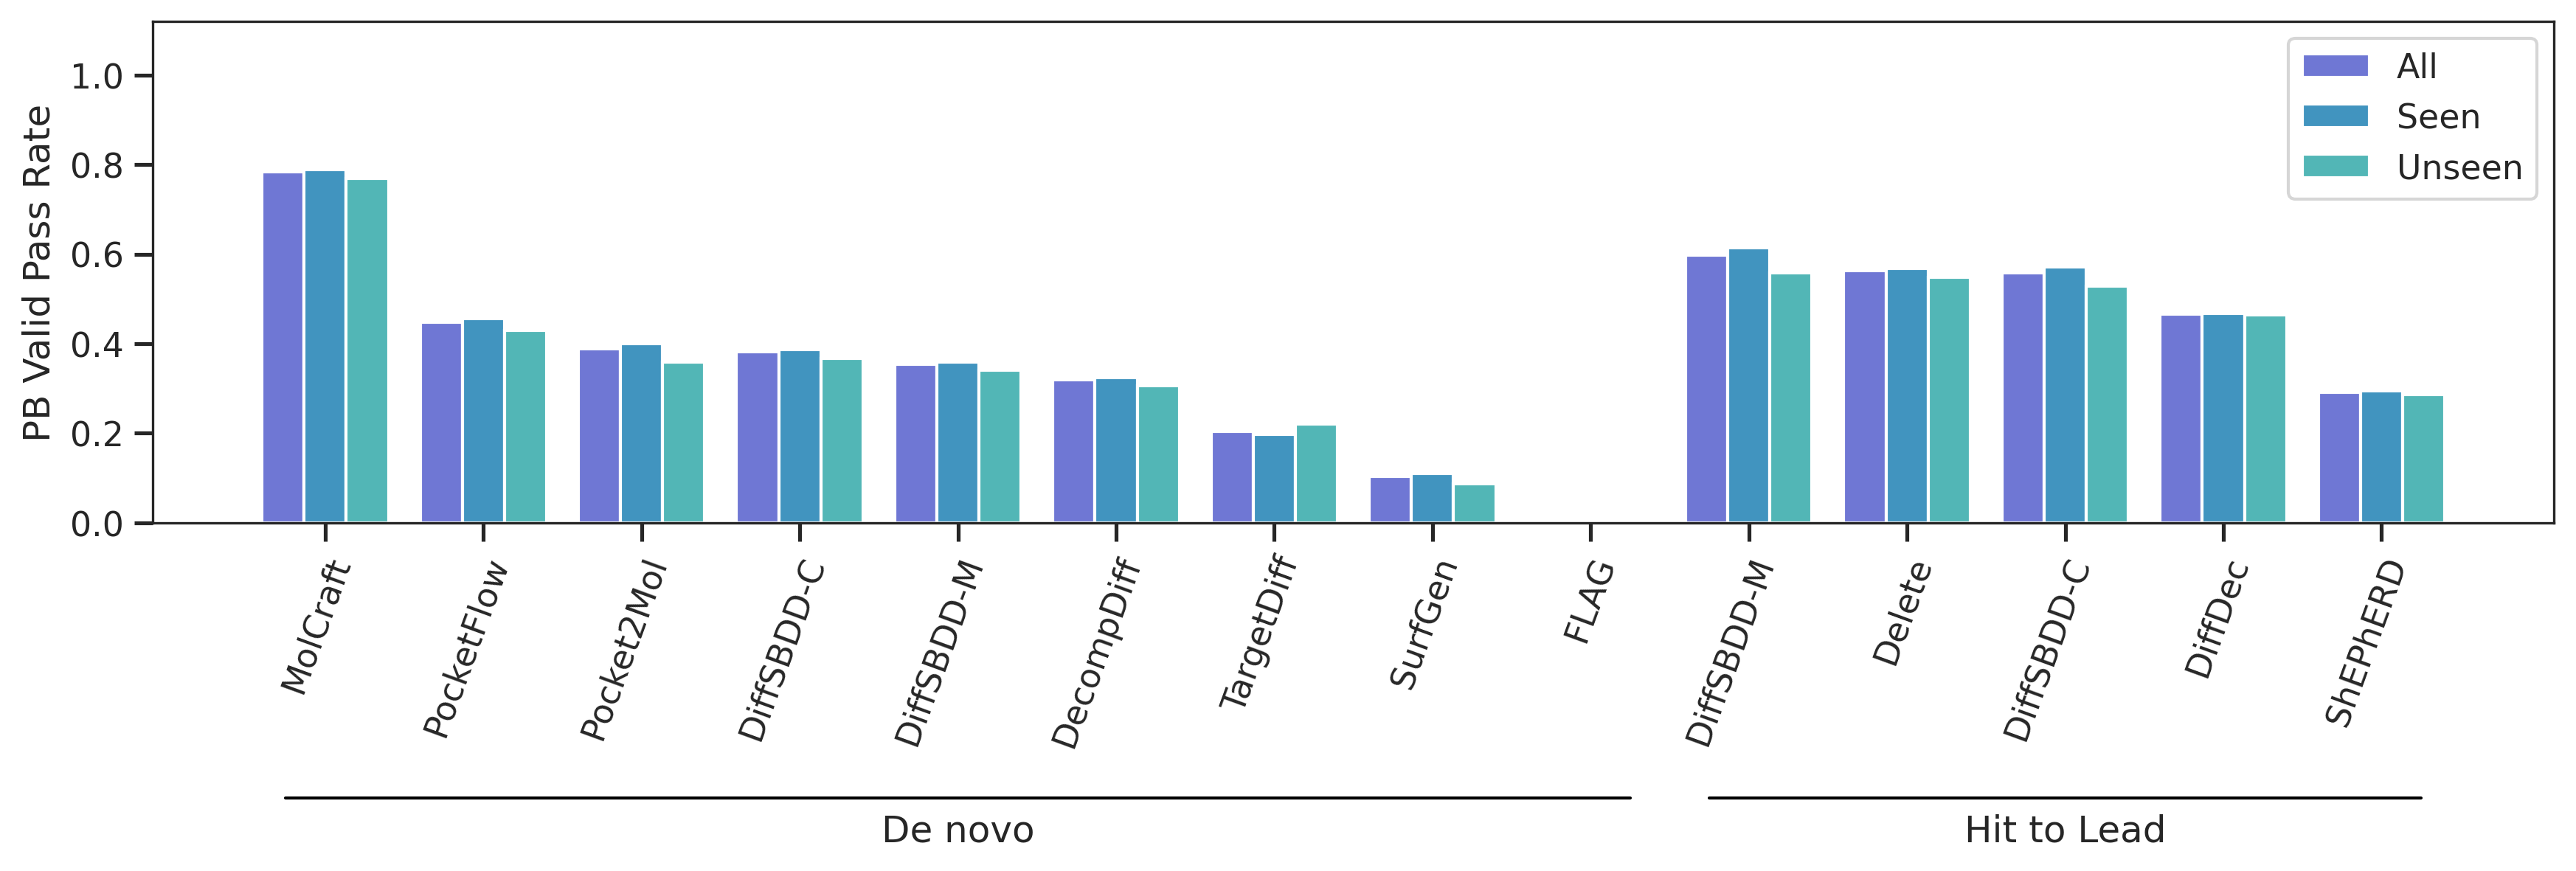

In [7]:
import os
import pandas as pd
import numpy as np
import yaml
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap


# ========== 数据读取 ==========
data_path = "/home/user-home/fanzhehuan/myprojects/MolGenBench/logs/260122"

round_list = ["Round1", "Round2", "Round3"]
mode_list = ["De_novo_Results", "Hit_to_Lead_Results"]

TASK_LIST_DENOVO = [
    'MolCraft_generated_molecules',
    'DecompDiff_generated_molecules',
    'FLAG_generated_molecules',
    'PocketFlow_generated_molecules',
    'SurfGen_generated_molecules',
    'TargetDiff_generated_molecules',
    "Pocket2Mol_generated_molecules",
    "diffSBDD_cond_crossdocked_generated_molecules",
    "diffSBDD_cond_moad_generated_molecules"
]

DENOVO_NAME_MAPPING = {
    "MolCraft_generated_molecules": "MolCraft",
    "DecompDiff_generated_molecules": "DecompDiff",
    "FLAG_generated_molecules": "FLAG",
    "PocketFlow_generated_molecules": "PocketFlow",
    "SurfGen_generated_molecules": "SurfGen",
    "TargetDiff_generated_molecules": "TargetDiff",
    "Pocket2Mol_generated_molecules": "Pocket2Mol",
    "diffSBDD_cond_crossdocked_generated_molecules": "DiffSBDD-C",
    "diffSBDD_cond_moad_generated_molecules": "DiffSBDD-M",
}

TASK_LIST_H2L = [
    "DeleteHit2Lead(CrossDock)_Hit_to_Lead",
    "DiffDec_Hit_to_Lead",
    "diffSBDD_cond_crossdocked_Hit_to_Lead",
    "diffSBDD_cond_moad_Hit_to_Lead",
    # "ShapeMol_Hit_to_Lead",  # 去除 ShapeMol
    "shepherd_x1x3x4_mosesaq_submission_Hit_to_Lead",
]

H2L_NAME_MAPPING = {
    "DiffDec_Hit_to_Lead": "DiffDec",
    "diffSBDD_cond_crossdocked_Hit_to_Lead": "DiffSBDD-C",
    "diffSBDD_cond_moad_Hit_to_Lead": "DiffSBDD-M",
    # "ShapeMol_Hit_to_Lead": "ShapeMol",
    "shepherd_x1x3x4_mosesaq_submission_Hit_to_Lead": "ShEPhERD",
    "DeleteHit2Lead(CrossDock)_Hit_to_Lead": "Delete",
}

all_key = [
    "mol_cond_loaded",
    "sanitization",
    "inchi_convertible",
    "all_atoms_connected",
    "bond_lengths",
    "bond_angles",
    "internal_steric_clash",
    "aromatic_ring_flatness",
    "double_bond_flatness",
    "internal_energy",
    "protein-ligand_maximum_distance",
    "minimum_distance_to_protein",
    "minimum_distance_to_organic_cofactors",
    "minimum_distance_to_inorganic_cofactors",
    "minimum_distance_to_waters",
    "volume_overlap_with_protein",
    "volume_overlap_with_organic_cofactors",
    "volume_overlap_with_inorganic_cofactors",
    "volume_overlap_with_waters",
    "pass_all",
]

results_all = []
results_seen = []
results_unseen = []

for round_name in round_list:
    for mode in mode_list:
        if mode == "De_novo_Results":
            task_list = TASK_LIST_DENOVO
            name_mapping = DENOVO_NAME_MAPPING
            task_type = "De novo"
        else:
            task_list = TASK_LIST_H2L
            name_mapping = H2L_NAME_MAPPING
            task_type = "Hit to Lead"
        
        for task in task_list:
            yaml_path = os.path.join(data_path, round_name, mode, task, "results.yaml")
            if not os.path.exists(yaml_path):
                print(f"Warning: {yaml_path} not found")
                continue
                
            with open(yaml_path, 'r') as f:
                result = yaml.safe_load(f)

                results_all.append({
                    "Model": name_mapping[task],
                    "Round": round_name,
                    "Type": task_type,
                    **result['metrics']['PoseBuster']['all'],
                })
                
                results_seen.append({
                    "Model": name_mapping[task],
                    "Round": round_name,
                    "Type": task_type,
                    **result['metrics']['PoseBuster']['seen'],
                })
                
                results_unseen.append({
                    "Model": name_mapping[task],
                    "Round": round_name,
                    "Type": task_type,
                    **result['metrics']['PoseBuster']['unseen'],
                })

df_results_all = pd.DataFrame(results_all)
df_results_seen = pd.DataFrame(results_seen)
df_results_unseen = pd.DataFrame(results_unseen)

# 聚合数据（计算 3 个 Round 的均值）
df_mean_all = df_results_all.groupby(["Model", "Type"], as_index=False)[all_key].mean()
df_mean_seen = df_results_seen.groupby(["Model", "Type"], as_index=False)[all_key].mean()
df_mean_unseen = df_results_unseen.groupby(["Model", "Type"], as_index=False)[all_key].mean()


# ========== 将 DataFrame 转换为 plot_pbvalid_bar 所需的嵌套字典格式 ==========
def df_to_nested_dict(df_mean):
    """
    将 df_mean 转换为嵌套字典格式:
    {
        "De novo": {
            "MolCraft": {"pass_all": 0.5, "bond_lengths": 0.8, ...},
            ...
        },
        "Hit to Lead": {
            "Delete": {...},
            ...
        }
    }
    注意：需要将 'pass_all' 重命名为 'PBvalid_pass_all' 以匹配绘图函数
    """
    data_dict = {
        "De novo": {},
        "Hit to Lead": {}
    }
    
    for _, row in df_mean.iterrows():
        model_name = row["Model"]
        task_type = row["Type"]
        
        # 提取所有 metric 值（排除 Model 和 Type 列）
        metrics_dict = row.drop(["Model", "Type"]).to_dict()
        
        # 将 'pass_all' 重命名为 'PBvalid_pass_all' 以匹配绘图函数
        if 'pass_all' in metrics_dict:
            metrics_dict['PBvalid_pass_all'] = metrics_dict.pop('pass_all')
        
        data_dict[task_type][model_name] = metrics_dict
    
    return data_dict


# 转换数据
data_all = df_to_nested_dict(df_mean_all)
data_seen = df_to_nested_dict(df_mean_seen)
data_unseen = df_to_nested_dict(df_mean_unseen)


# ========== 绘图函数 ==========
def plot_pbvalid_bar(data_all, data_seen, data_unseen, save_file=None):

    def build_df(data, label):
        return pd.DataFrame({
            "Model": list(data.get('De novo', {}).keys()) + list(data.get('Hit to Lead', {}).keys()),
            "PB Valid": [m.get('PBvalid_pass_all', np.nan) for m in data.get('De novo', {}).values()] +
                        [m.get('PBvalid_pass_all', np.nan) for m in data.get('Hit to Lead', {}).values()],
            "Task": ["De novo"] * len(data.get('De novo', {})) + ["Hit to Lead"] * len(data.get('Hit to Lead', {})),
            "Group": label
        })

    df_all = build_df(data_all, "All")
    df_seen = build_df(data_seen, "Seen")
    df_unseen = build_df(data_unseen, "Unseen")

    # 只取 All 数据，按 De novo/Hit to Lead 分开排序
    order_denovo = df_all[df_all["Task"] == "De novo"].sort_values("PB Valid", ascending=False)["Model"].tolist()
    order_hit2lead = df_all[df_all["Task"] == "Hit to Lead"].sort_values("PB Valid", ascending=False)["Model"].tolist()
    
    df_final = pd.concat([df_all, df_seen, df_unseen], ignore_index=True)
    df_final["X"] = df_final["Task"] + "_" + df_final["Model"]
    order_y = [f"De novo_{m}" for m in order_denovo] + [f"Hit to Lead_{m}" for m in order_hit2lead]

    sns.set(style="ticks")
    # 画图
    palette = {
        "All": "#5E69E5",   # 深绿蓝
        "Seen": "#2C9AD4",  # 中青
        "Unseen": "#41C7C7" # 浅绿青
    }
    plt.figure(figsize=(14, 3), dpi=300)
    ax = sns.barplot(
        data=df_final,
        x="X",
        y="PB Valid",
        hue="Group",
        palette=palette,
        errorbar=None,
        order=order_y,
    )

    ax.set_ylabel("PB Valid Pass Rate", fontsize=12)
    ax.set_xlabel("")
    plt.legend(title="", loc='upper right')
    
    # 设置 x 轴标签为模型名（允许重复）
    new_labels = [lab.split("_", 1)[1] for lab in order_y]
    ax.set_xticklabels(new_labels, rotation=70, ha="right", rotation_mode='anchor')
    ax.set_ylim(0, 1.12)

    # 分组标注
    n_denovo = len(order_denovo)
    n_total = len(order_y)
    y_line = -0.55
    offset = 0.25
    line_width = 1.0

    # De novo bracket
    if n_denovo > 0:
        ax.plot([0 - offset, n_denovo - 1 + offset], [y_line, y_line], 
                color='black', lw=line_width, clip_on=False, transform=ax.get_xaxis_transform())
        ax.text((0 + n_denovo - 1) / 2, y_line - 0.10, "De novo", 
                ha='center', va='top', fontsize=12)

    # Hit to Lead bracket
    if n_total - n_denovo > 0:
        start = n_denovo
        end = n_total - 1
        ax.plot([start - offset, end + offset], [y_line, y_line], 
                color='black', lw=line_width, clip_on=False, transform=ax.get_xaxis_transform())
        ax.text((start + end) / 2, y_line - 0.10, "Hit to Lead", 
                ha='center', va='top', fontsize=12)

    # 框线线宽调小
    for spine in ["top", "right", "left", "bottom"]:
        ax.spines[spine].set_linewidth(0.8)
    
    if save_file:
        plt.savefig(save_file, format="svg", bbox_inches="tight")
    plt.show()
    plt.close()


# ========== 调用绘图 ==========
save_dir = "./final_plot/output"
os.makedirs(save_dir, exist_ok=True)

plot_pbvalid_bar(
    data_all, 
    data_seen, 
    data_unseen, 
    save_file=os.path.join(save_dir, "07-posebuster_PBvalid_bar.svg")
)